In [1]:
%load_ext autoreload
%autoreload 2

In [13]:
import glob
import os
from EDA import load_braking_data, plot_all_signals, plot_voltage_current
from XGBoost import prepare_xgb_features, create_xgb_training_data, train_and_predict_xgb, evaluate_and_plot_xgb
from arc_detection import  detect_instabilities, plot_instabilities, extract_correlations, plot_correlation_boxplot
from Isolation_Forest import prepare_iforest_features, train_and_predict_loocv, evaluate_and_plot
from Autoencoder import prepare_ae_features, train_and_predict_ae, evaluate_and_plot_ae, prepare_raw_ae_features, train_and_predict_raw_ae, evaluate_and_plot_raw_ae

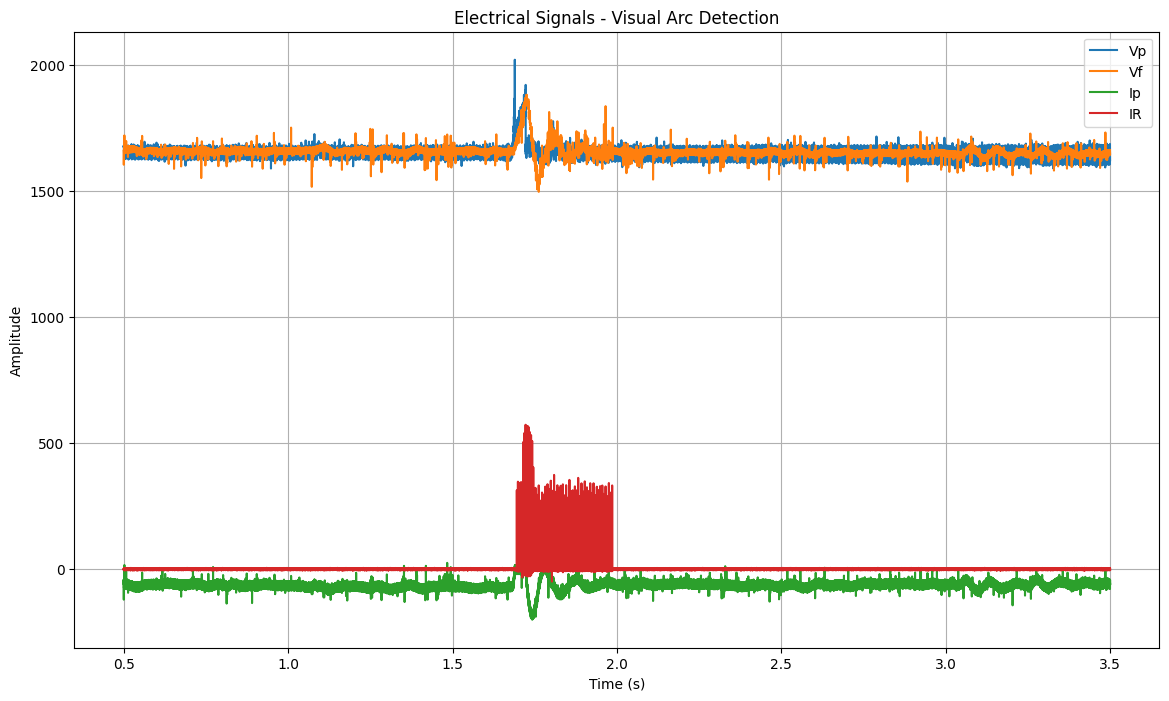

In [3]:
# Load and plot all signals for record 1
df_all = load_braking_data(braking_id="1", variables=["Vp", "Vf", "Ip", "IR"])
plot_all_signals(df_all)

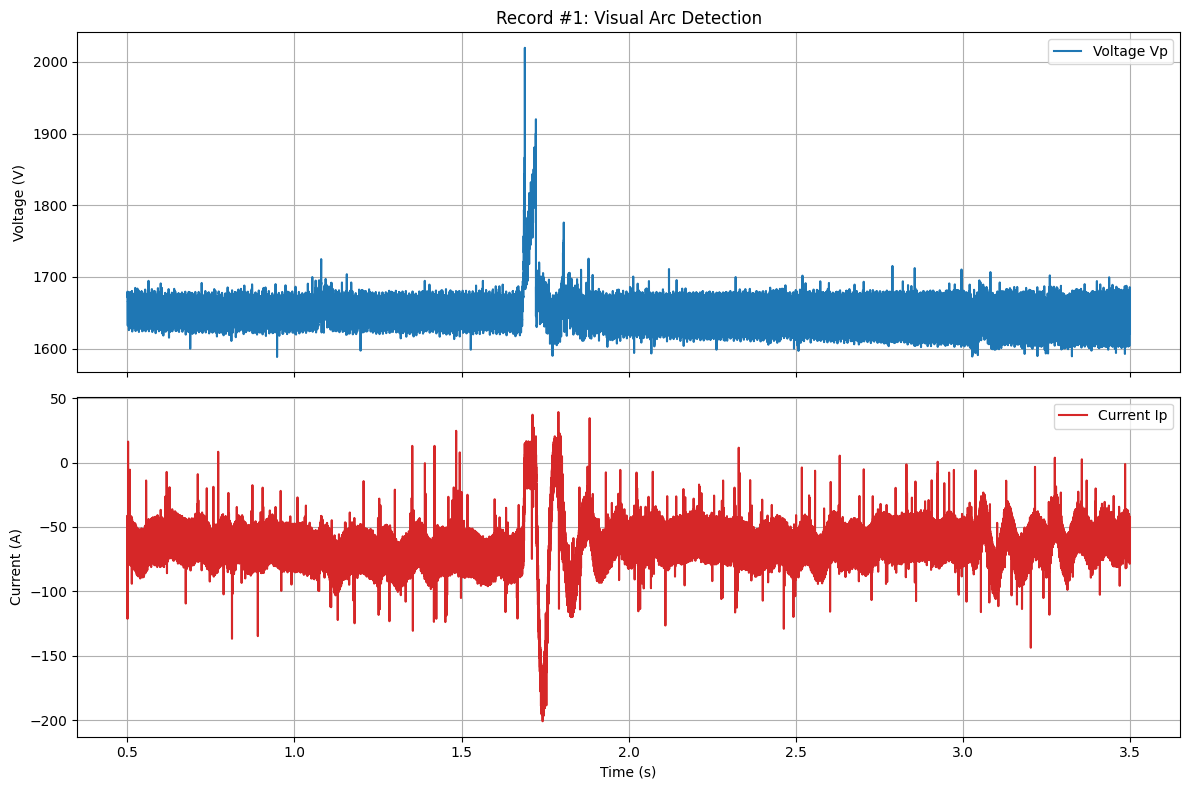

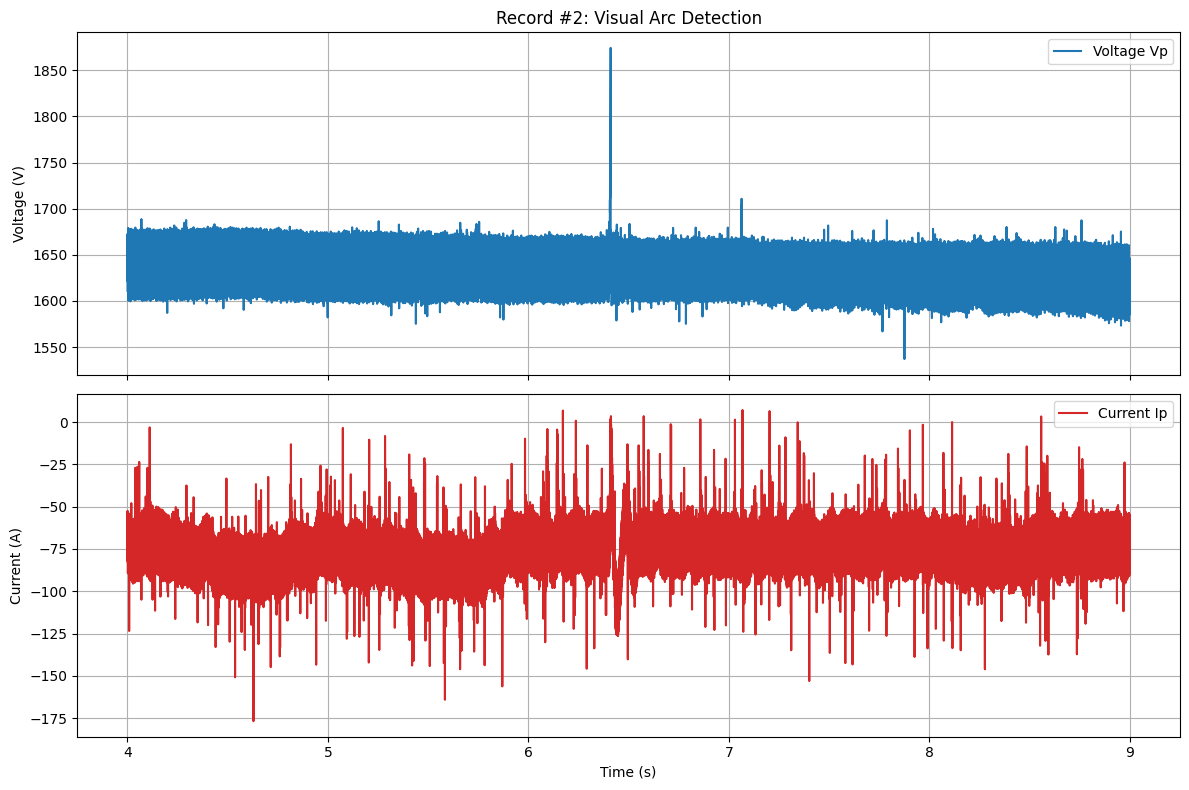

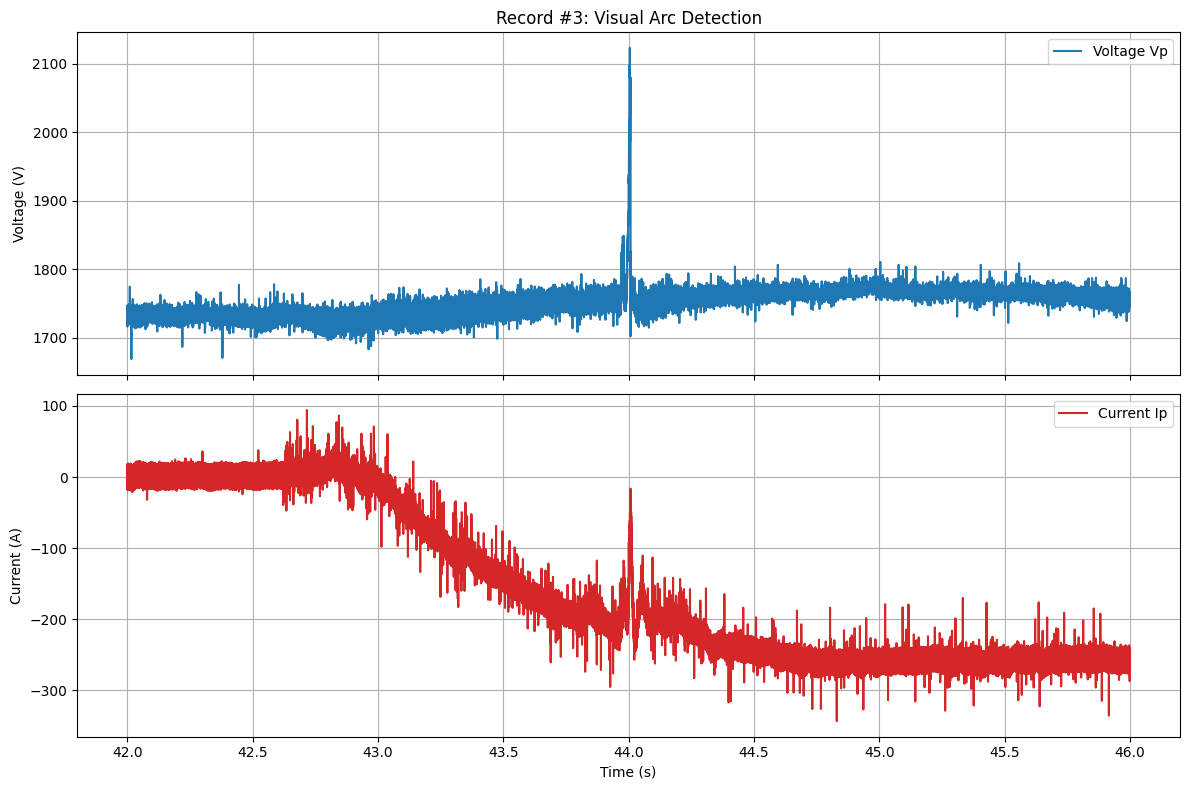

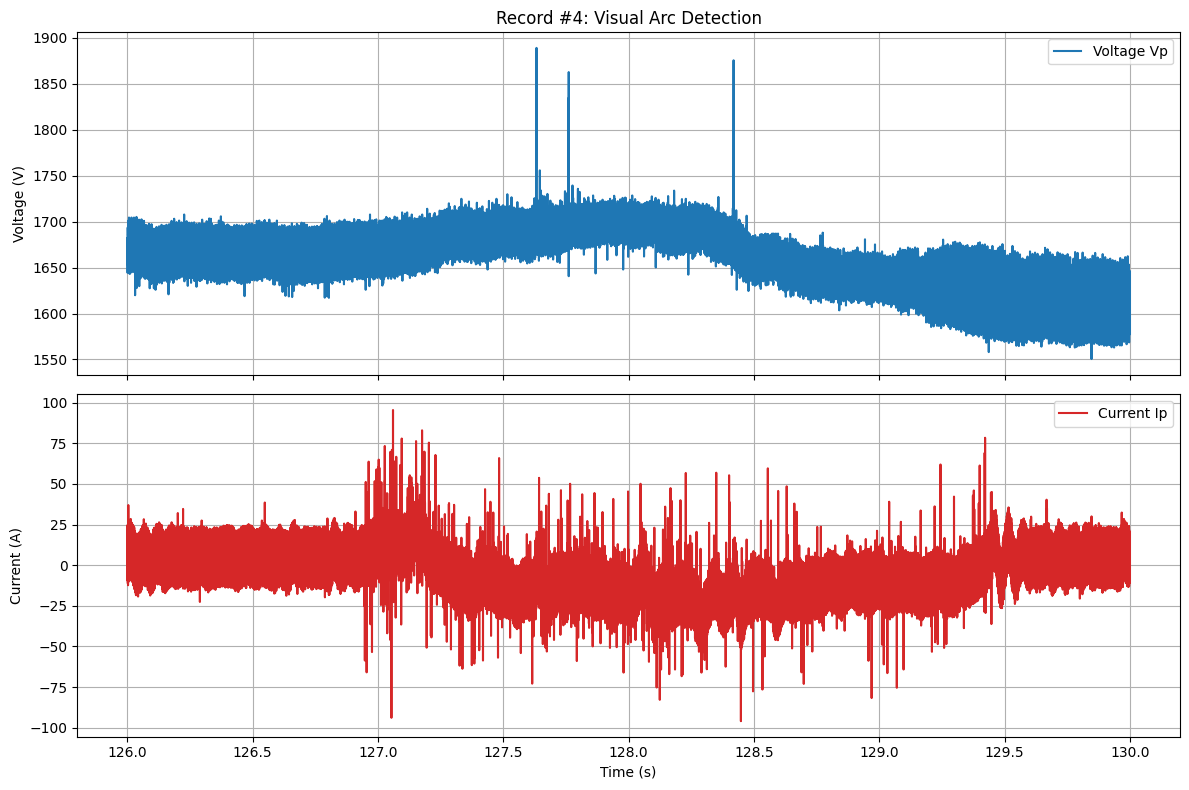

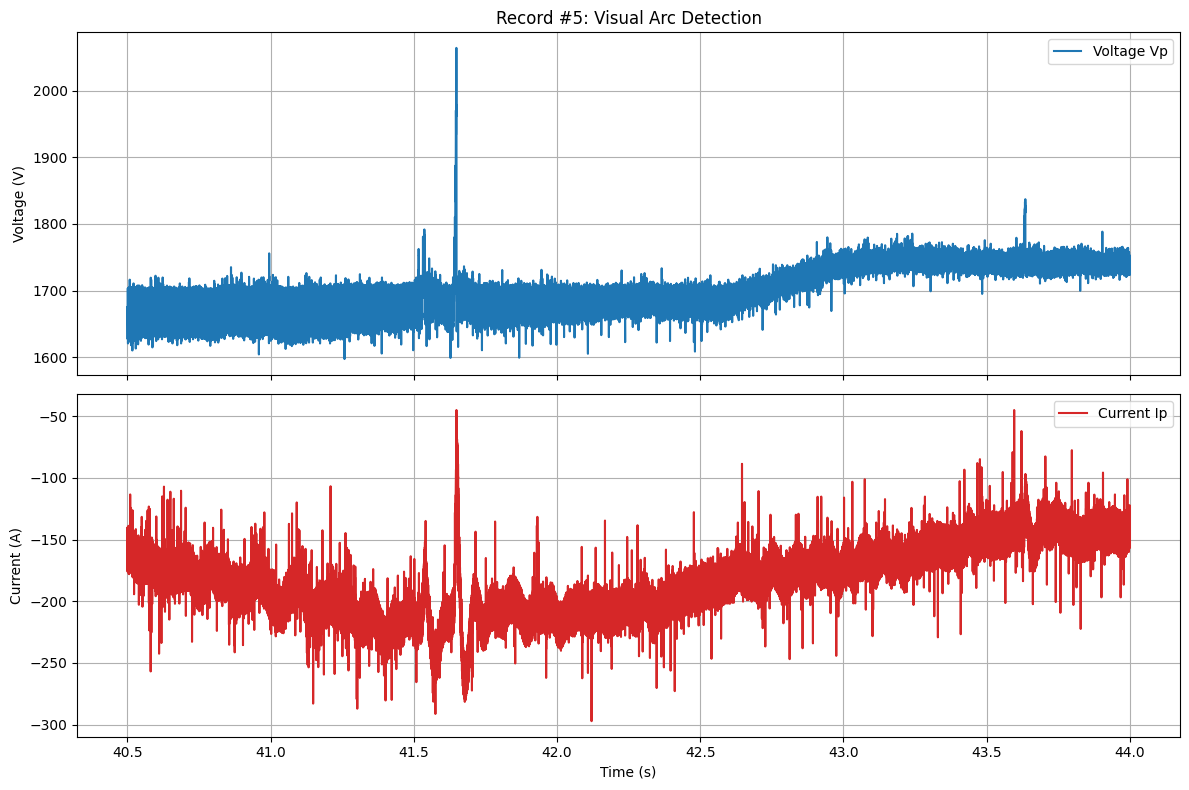

In [12]:
# Process and plot subplots for all matching files
file_list = glob.glob("Fichiers/MM_B_*_Vp.txt")

for file_path in sorted(file_list):
    braking_id = file_path.split('_')[2]
    
    # Define paths for the required complementary files
    file_x = f"Fichiers/MM_B_{braking_id}_x.txt"
    file_ip = f"Fichiers/MM_B_{braking_id}_Ip.txt"
    
    # Check if all needed files exist before processing
    if os.path.exists(file_x) and os.path.exists(file_ip):
        df_vp_ip = load_braking_data(braking_id, variables=["Vp", "Ip"])
        plot_voltage_current(df_vp_ip, braking_id)
    else:
        print(f"Missing data files for record #{braking_id}, skipping plot.")

Record 1: Anomalie détectée à t = 1.6895s


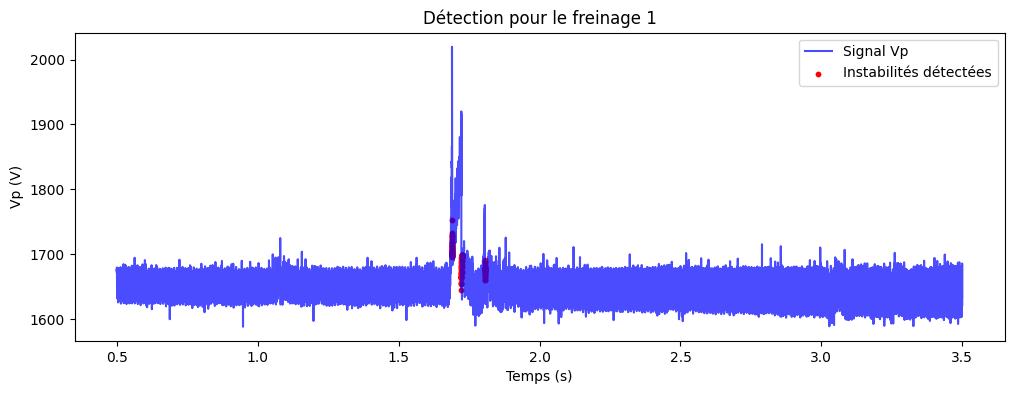

Record 2: Anomalie détectée à t = 6.4103s


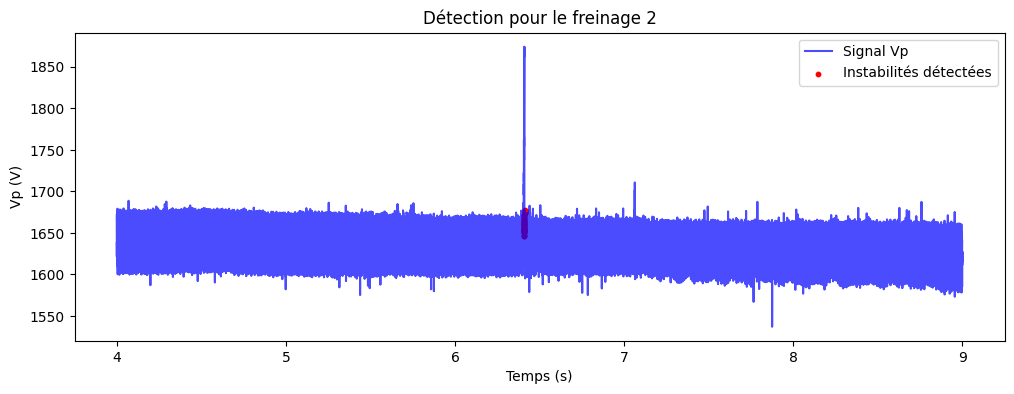

Record 3: Anomalie détectée à t = 43.9770s


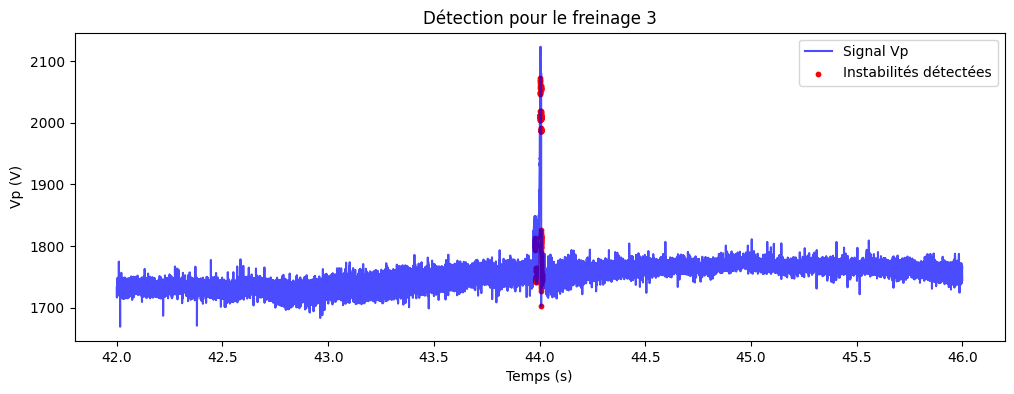

Record 4: Anomalie détectée à t = 127.6324s


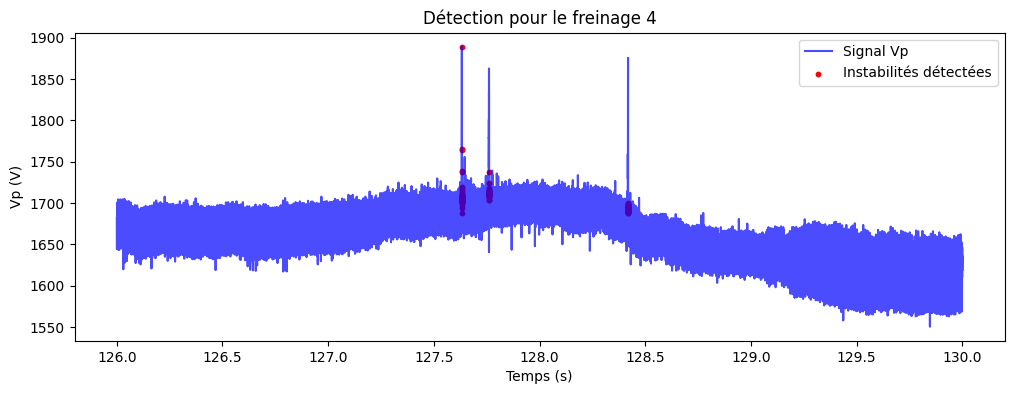

Record 5: Anomalie détectée à t = 41.5393s


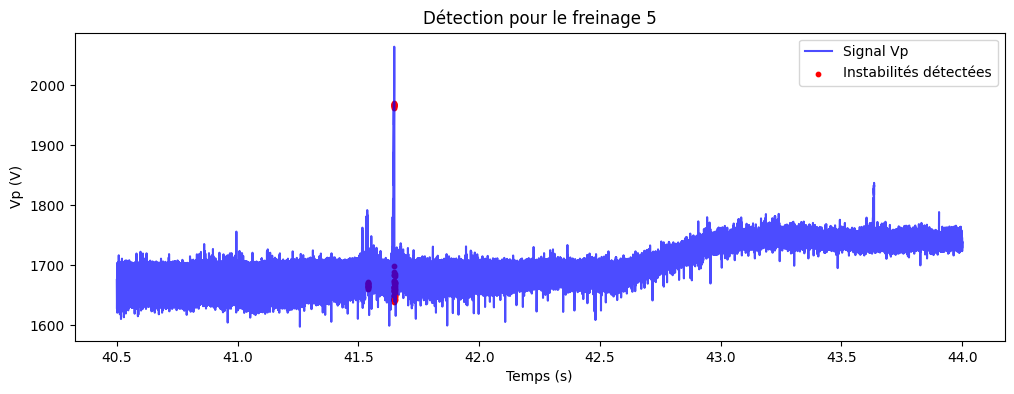

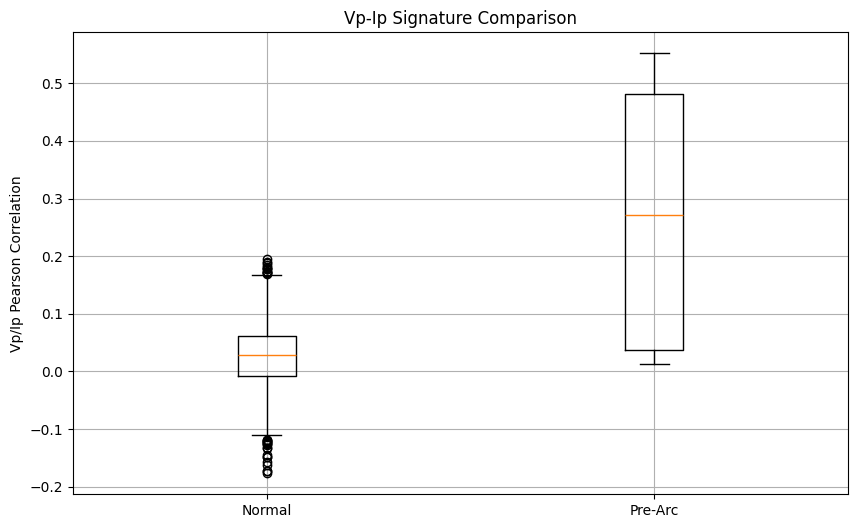

In [ ]:
# Parameters
WINDOW_SIZE = 50
PRE_ARC_WINDOW = 10000
SIGMA_THRESHOLD = 5

all_normal_corrs = []
all_pre_arc_corrs = []

vp_files = glob.glob("Fichiers/MM_B_*_Vp.txt")
braking_ids = sorted(list(set([f.split('_')[2] for f in vp_files])))


for b_id in braking_ids:
    # 1. Load data (Using the function we created previously with os.path.exists)
    file_x = f"Fichiers/MM_B_{b_id}_x.txt"
    file_ip = f"Fichiers/MM_B_{b_id}_Ip.txt"
    
    if not (os.path.exists(file_x) and os.path.exists(file_ip)):
        continue # Skip if missing files
        
    df = load_braking_data(b_id, variables=["Vp", "Ip"])
    
    if len(df) < (PRE_ARC_WINDOW * 2):
        continue
        
    # 2. Detect anomalies
    unstable_indices = detect_instabilities(df, WINDOW_SIZE, SIGMA_THRESHOLD)
    
    # 3. Plot anomalies (if any)
    if unstable_indices:
        onset_time = df['time'].iloc[unstable_indices[0]]
        print(f"Record {b_id}: Anomalie détectée à t = {onset_time:.4f}s")
        plot_instabilities(df, unstable_indices, b_id)
        
    # 4. Extract and store correlations
    norm_c, pre_arc_c = extract_correlations(df, unstable_indices, PRE_ARC_WINDOW)
    all_normal_corrs.extend(norm_c)
    all_pre_arc_corrs.extend(pre_arc_c)

plot_correlation_boxplot(all_normal_corrs, all_pre_arc_corrs)

Isolation Forest


  > True anomaly at: 1.6895s
  > First AI alarm raised at: 1.6905s
  DELAY: Detected 0.0010 sec after the arc.
  Total false alarms (noise points): 0


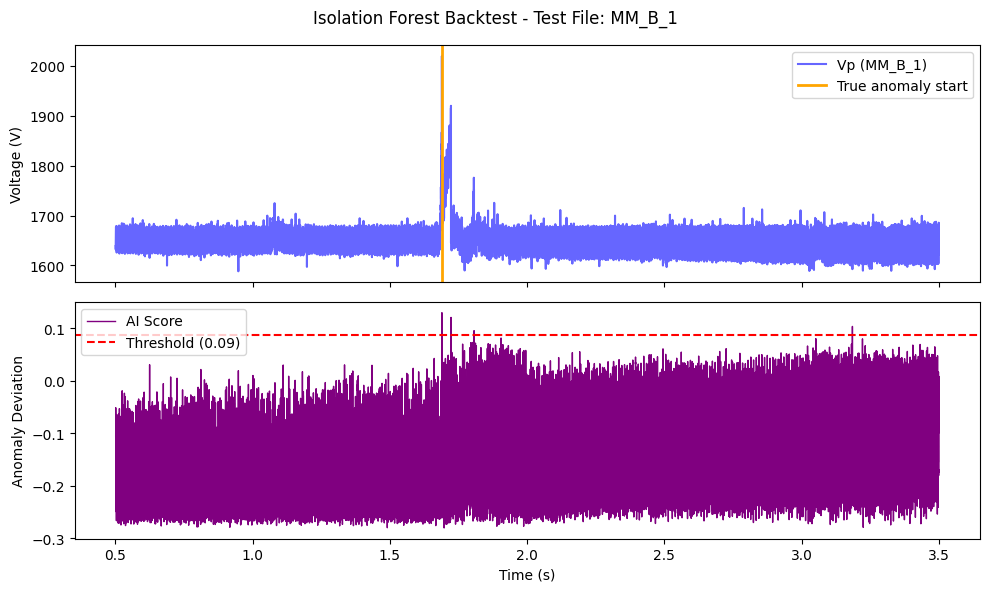


  > True anomaly at: 6.4103s
  FAILURE: AI never exceeded the threshold.


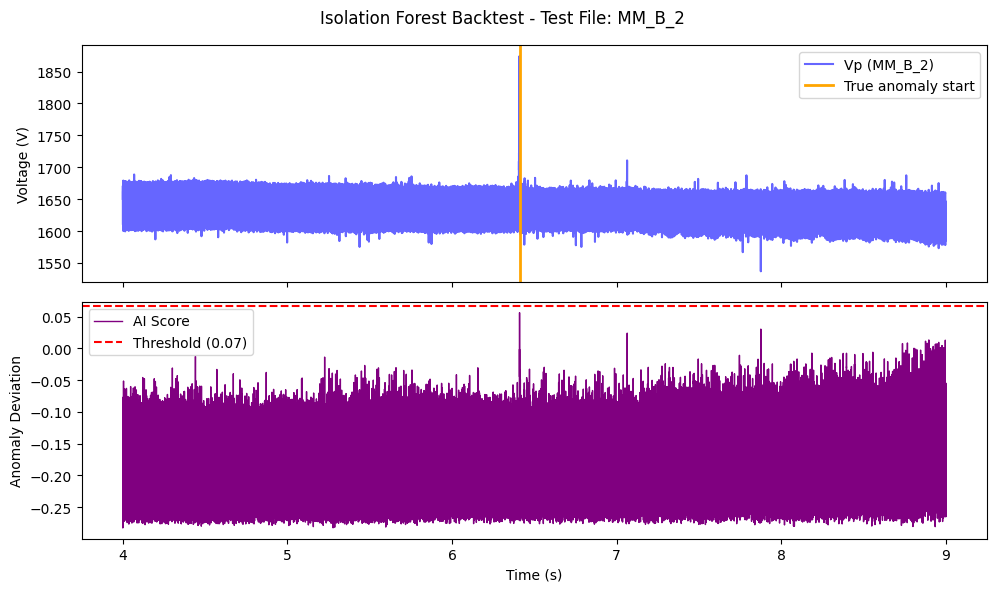


  > True anomaly at: 43.9770s
  > First AI alarm raised at: 42.0165s
  PREMATURE: Alarm triggered way too early (False Alarm).
  Total false alarms (noise points): 23


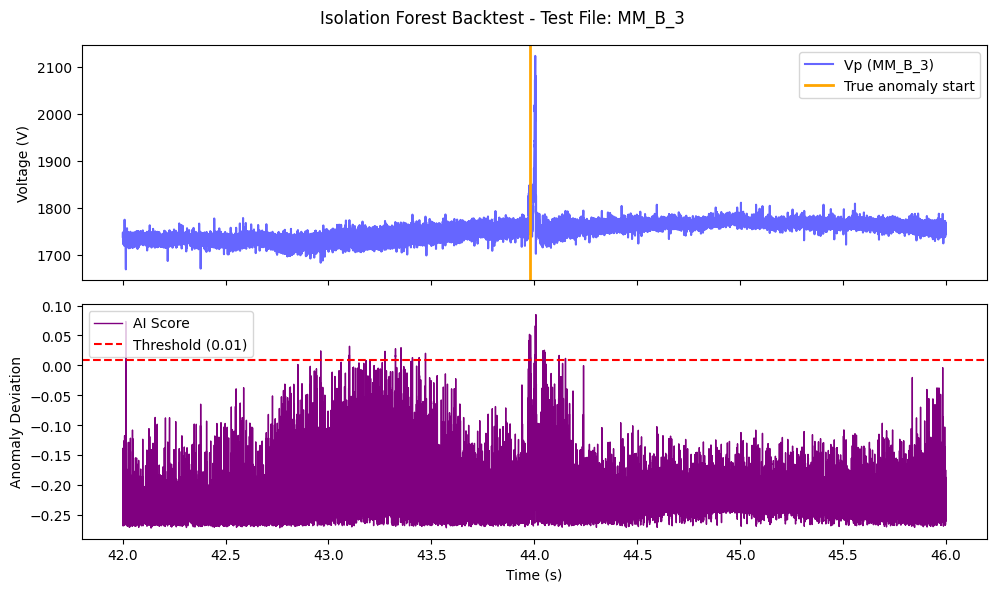


  > True anomaly at: 127.6324s
  > First AI alarm raised at: 127.6333s
  DELAY: Detected 0.0009 sec after the arc.
  Total false alarms (noise points): 0


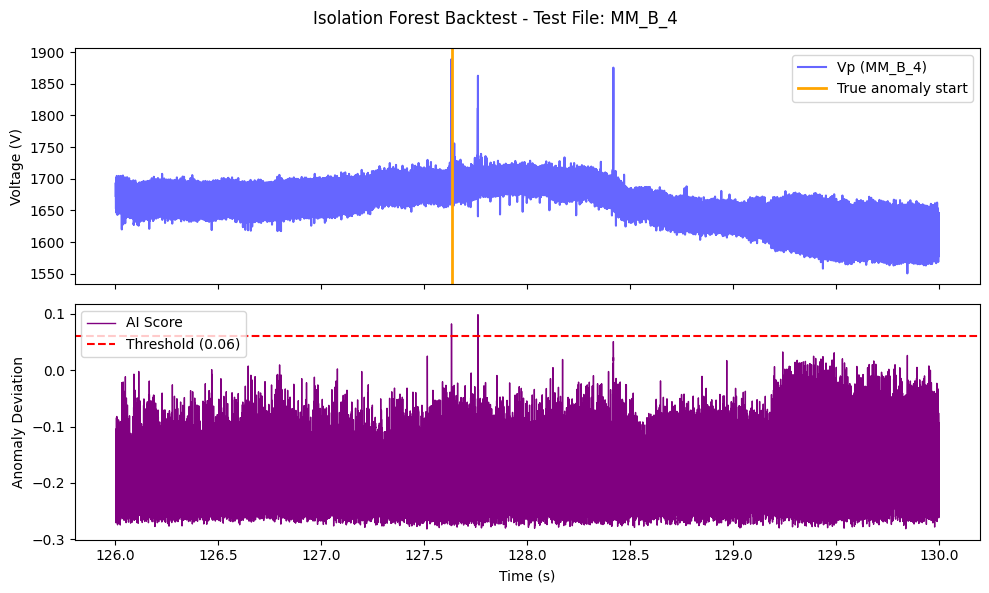


  > True anomaly at: 41.5393s
  > First AI alarm raised at: 41.6500s
  DELAY: Detected 0.1107 sec after the arc.
  Total false alarms (noise points): 0


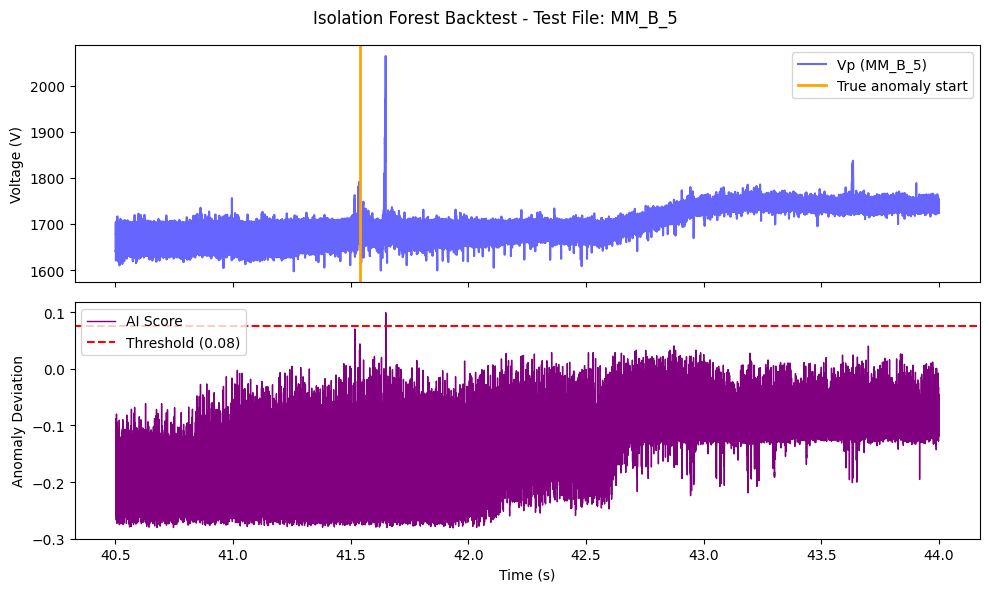

In [ ]:
WINDOW_SIZE = 50
CALIBRATION_POINTS = 1000
NUM_TRAIN_POINTS = 15000 
THRESHOLD_MULTIPLIER = 0.02

FEATURES_TO_USE = ['Residual_scaled', 'Vp_Std_scaled', 'Speed_scaled']

TRUE_ANOMALY_TIMES = {
    "MM_B_1": 1.6895, "MM_B_2": 6.4103, "MM_B_3": 43.9770,
    "MM_B_4": 127.6324, "MM_B_5": 41.5393
}

# DATA LOADING & PREPARATION
all_data = {}
vp_files = sorted(glob.glob("Fichiers/MM_B_*_Vp.txt"))

for vp_file in vp_files:
    b_id = os.path.basename(vp_file).split('_')[2]
    id_to_test = f"MM_B_{b_id}"
    
    df = load_braking_data(b_id, variables=["Vp"])
    if df is not None:
        all_data[id_to_test] = prepare_iforest_features(df, WINDOW_SIZE, CALIBRATION_POINTS)
        
# LEAVE-ONE-OUT CROSS-VALIDATION (LOOCV)
for test_id, test_df in all_data.items():
    if test_id not in TRUE_ANOMALY_TIMES:
        continue
        
    train_dfs = [df for id_name, df in all_data.items() if id_name != test_id]
    
    # Train and predict
    test_results, max_train_score = train_and_predict_loocv(
        train_dfs, test_df, 
        feature_cols=FEATURES_TO_USE, 
        num_train_points=NUM_TRAIN_POINTS
    )
    # Calculate threshold and evaluate
    threshold = max_train_score + abs(max_train_score) * THRESHOLD_MULTIPLIER
    true_time = TRUE_ANOMALY_TIMES[test_id]
    
    evaluate_and_plot(test_results, threshold, true_time, test_id)

File MM_B_1: Ready.
File MM_B_2: Ready.
File MM_B_3: Ready.
File MM_B_4: Ready.
File MM_B_5: Ready.

  > True anomaly at: 1.6895s
  > First AI alarm raised at: 1.0809s
  SUCCESS: Correctly anticipated by 0.6086 sec.
  Total false alarms (noise points): 0


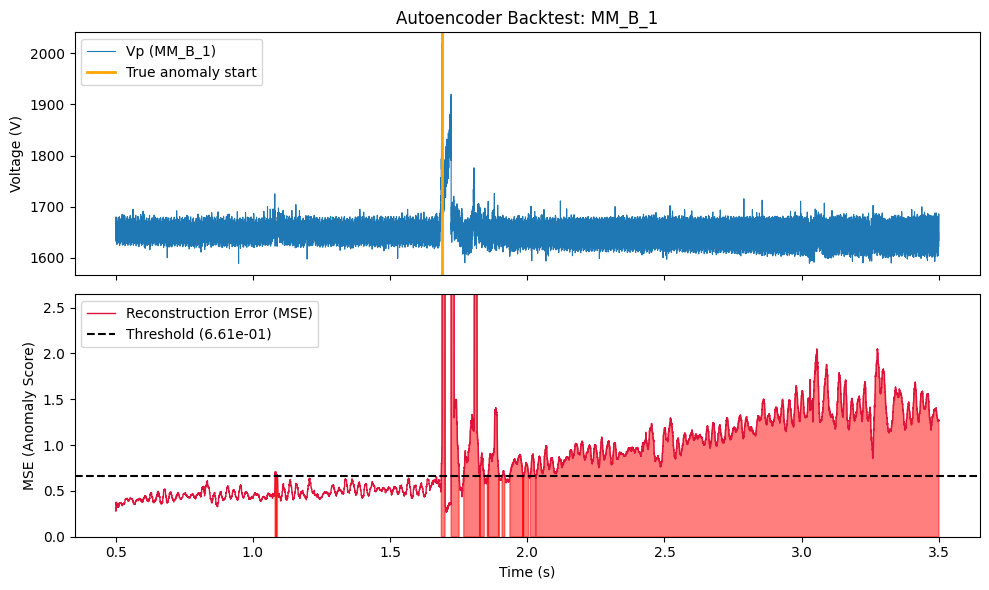


  > True anomaly at: 6.4103s
  > First AI alarm raised at: 4.4464s
  PREMATURE: Alarm triggered way too early (False Alarm).
  Total false alarms (noise points): 223


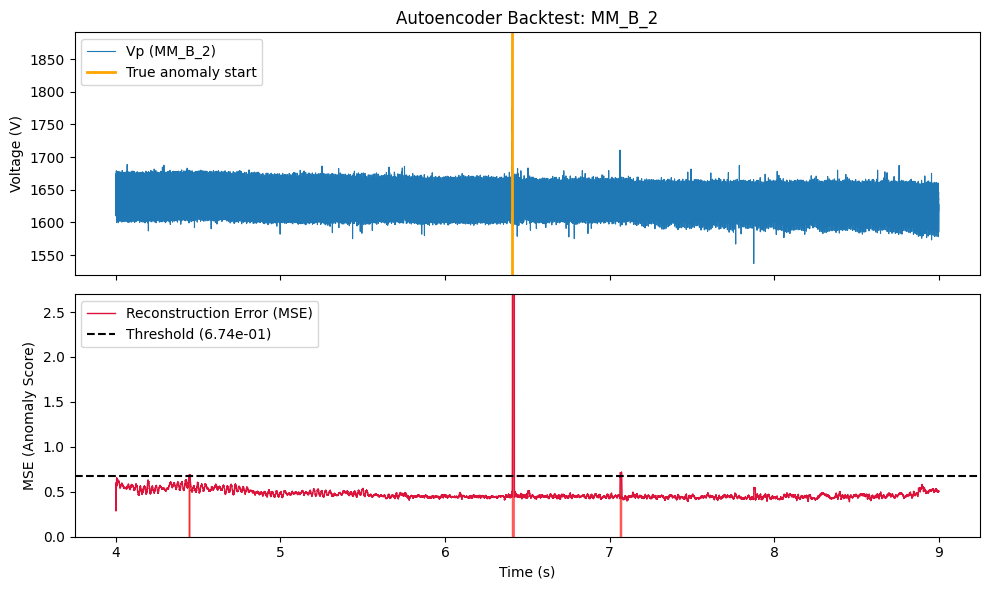


  > True anomaly at: 43.9770s
  > First AI alarm raised at: 42.8550s
  PREMATURE: Alarm triggered way too early (False Alarm).
  Total false alarms (noise points): 977


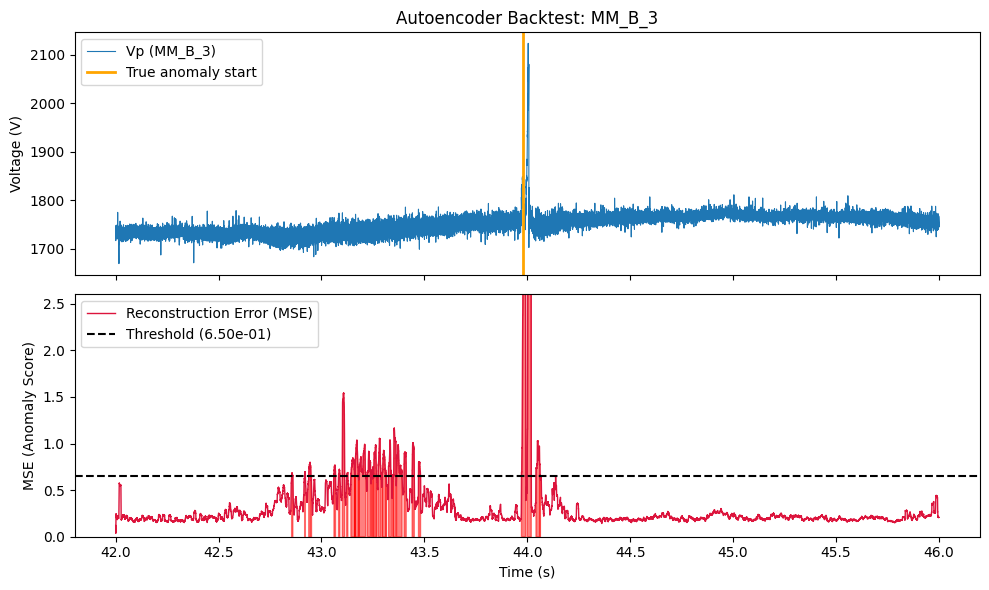


  > True anomaly at: 127.6324s
  > First AI alarm raised at: 126.6649s
  SUCCESS: Correctly anticipated by 0.9675 sec.
  Total false alarms (noise points): 0


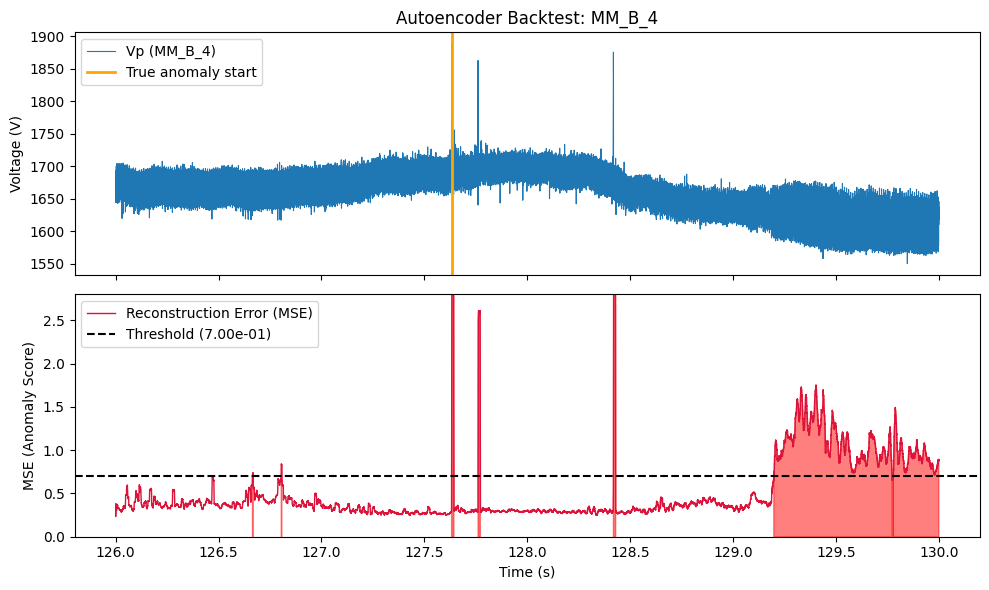


  > True anomaly at: 41.5393s
  > First AI alarm raised at: 41.5394s
  DELAY: Detected 0.0001 sec after the arc.
  Total false alarms (noise points): 0


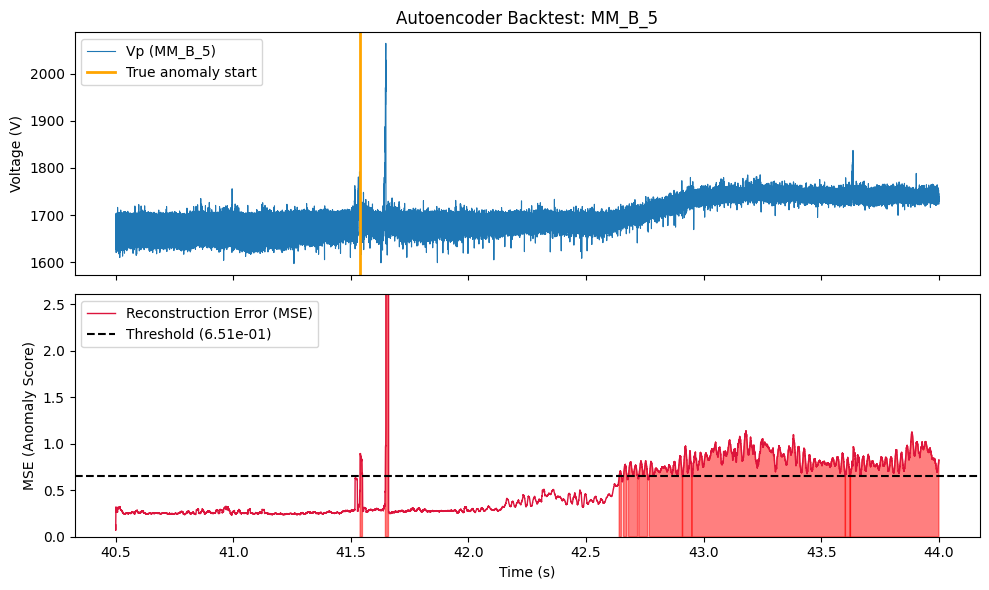

In [ ]:
WINDOW_SIZE = 50
CALIBRATION_POINTS = 1000
NUM_TRAIN_POINTS = 15000 
THRESHOLD_MARGIN = 1.2 

FEATURES_TO_USE = ['Residual_scaled', 'Vp_Std_scaled', 'Vp_Speed_scaled']

TRUE_ANOMALY_TIMES = {
    "MM_B_1": 1.6895, "MM_B_2": 6.4103, "MM_B_3": 43.9770,
    "MM_B_4": 127.6324, "MM_B_5": 41.5393
}

all_data = {}
vp_files = sorted(glob.glob("Fichiers/MM_B_*_Vp.txt"))

for vp_file in vp_files:
    b_id = os.path.basename(vp_file).split('_')[2]
    id_to_test = f"MM_B_{b_id}"
    
    df = load_braking_data(b_id, variables=["Vp"])
    if df is not None:
        all_data[id_to_test] = prepare_ae_features(df, WINDOW_SIZE, CALIBRATION_POINTS)
        print(f"File {id_to_test}: Ready.")

# LOOCV TRAINING & EVALUATION
for test_id, test_df in all_data.items():
    if test_id not in TRUE_ANOMALY_TIMES:
        continue
    
    train_dfs = [df for id_name, df in all_data.items() if id_name != test_id]
    
    # Train the Autoencoder and predict
    test_results, threshold = train_and_predict_ae(
        train_dfs, test_df, 
        feature_cols=FEATURES_TO_USE, 
        num_train_points=NUM_TRAIN_POINTS,
        threshold_margin=THRESHOLD_MARGIN
    )
    
    # Evaluate metrics and display plot
    true_time = TRUE_ANOMALY_TIMES[test_id]
    evaluate_and_plot_ae(test_results, threshold, true_time, test_id)

Autoencoder on raw features : 

--- Loading and Local Calibration (Raw Signals) ---
File MM_B_1: Ready.
File MM_B_2: Ready.
File MM_B_3: Ready.
File MM_B_4: Ready.
File MM_B_5: Ready.

--- Starting LOOCV Evaluation with Raw Autoencoder ---

> Evaluating test file: MM_B_1 using ['Vp_scaled', 'Ip_scaled', 'IR_scaled', 'Vf_scaled']

  > True anomaly at: 1.6895s
  > First AI alarm raised at: 1.0797s
  SUCCESS: Correctly anticipated by 0.6098 sec.
  Total false alarms: 0


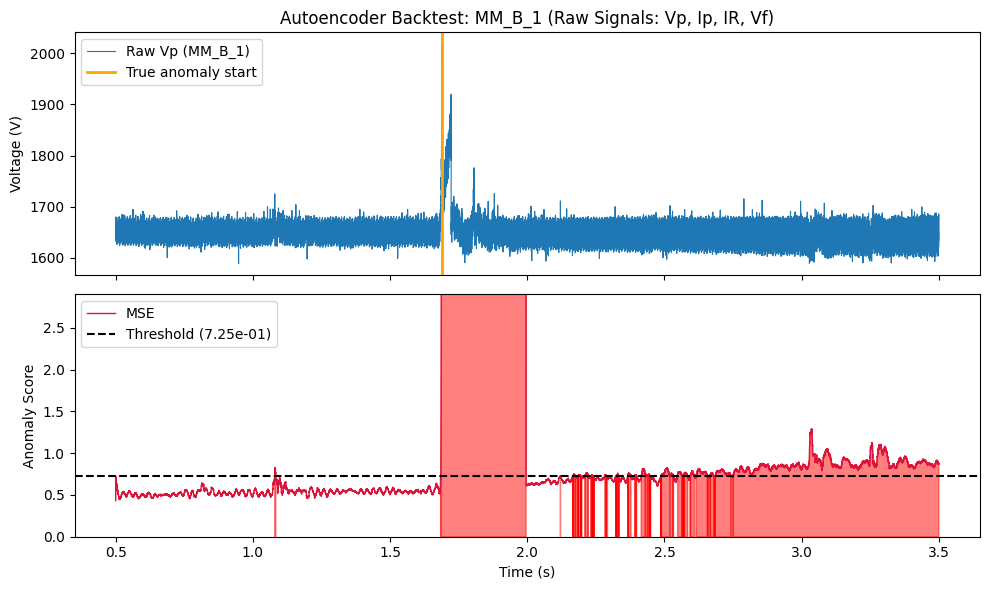


> Evaluating test file: MM_B_2 using ['Vp_scaled', 'Ip_scaled', 'IR_scaled', 'Vf_scaled']

  > True anomaly at: 6.4103s
  > First AI alarm raised at: 6.4080s
  SUCCESS: Correctly anticipated by 0.0023 sec.
  Total false alarms: 0


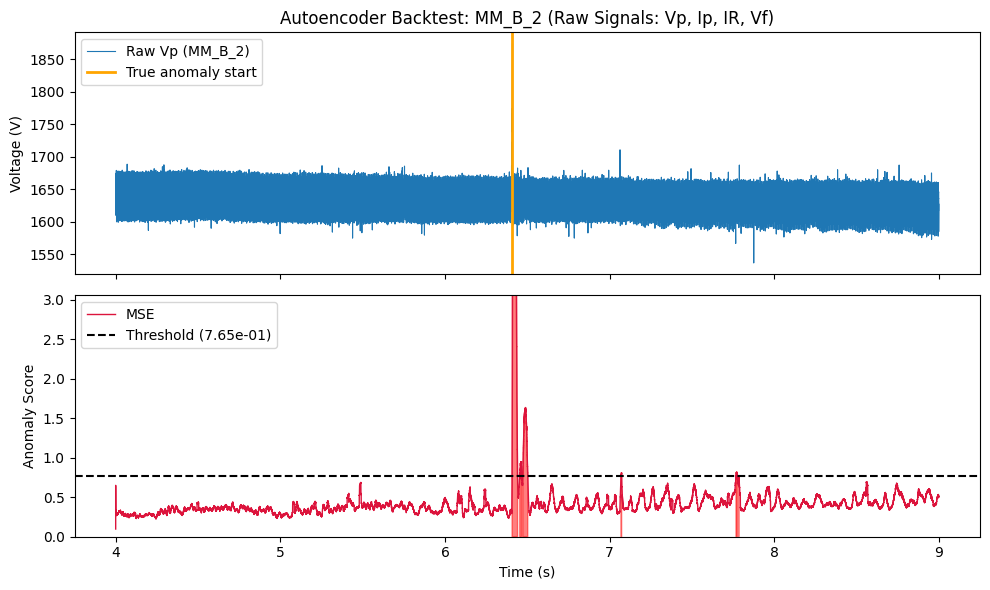


> Evaluating test file: MM_B_3 using ['Vp_scaled', 'Ip_scaled', 'IR_scaled', 'Vf_scaled']

  > True anomaly at: 43.9770s
  > First AI alarm raised at: 42.5358s
  PREMATURE: Alarm triggered way too early (False Alarm).
  Total false alarms: 19033


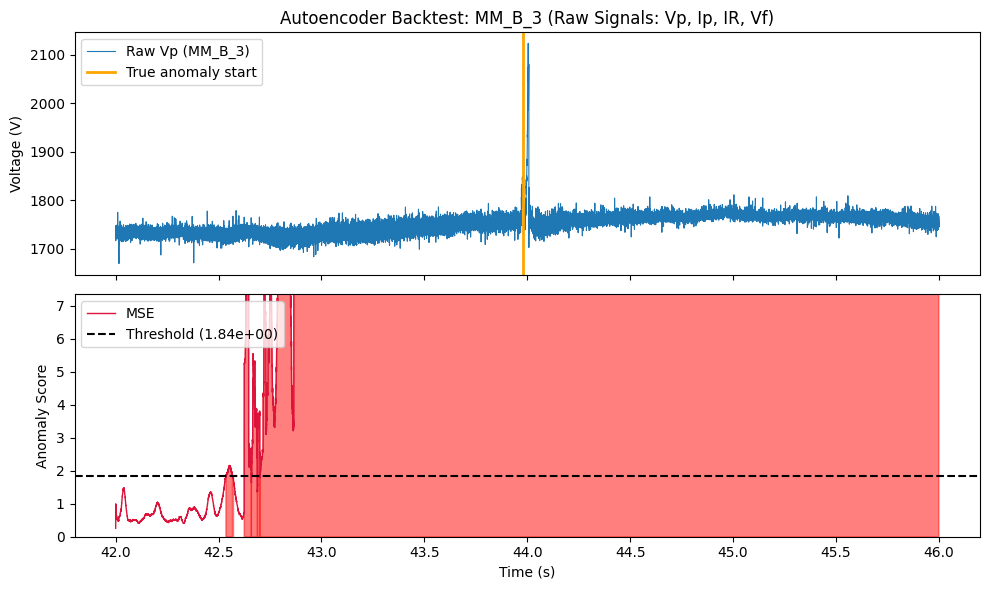


> Evaluating test file: MM_B_4 using ['Vp_scaled', 'Ip_scaled', 'IR_scaled', 'Vf_scaled']

  > True anomaly at: 127.6324s
  > First AI alarm raised at: 126.1124s
  PREMATURE: Alarm triggered way too early (False Alarm).
  Total false alarms: 572


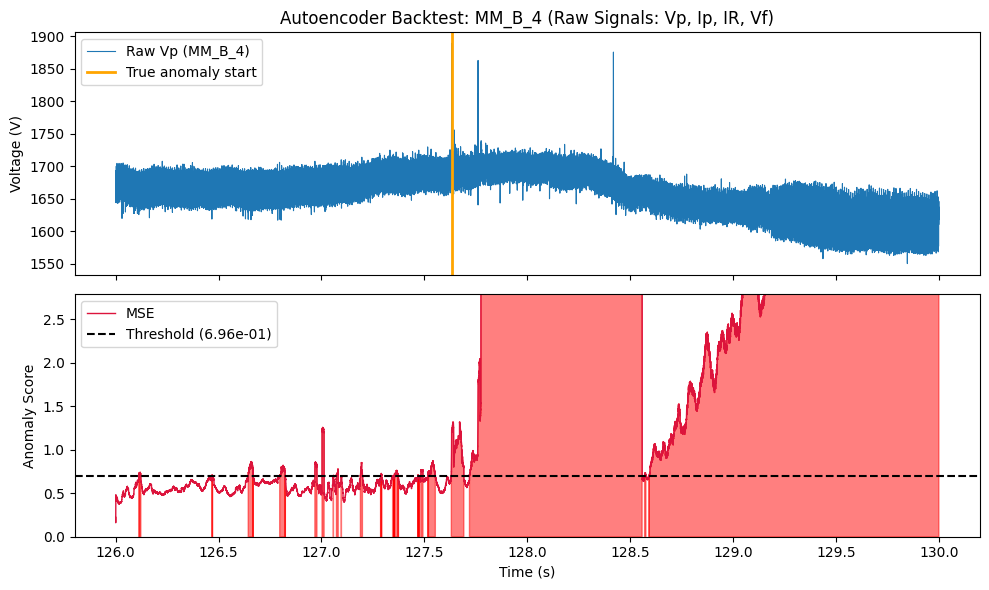


> Evaluating test file: MM_B_5 using ['Vp_scaled', 'Ip_scaled', 'IR_scaled', 'Vf_scaled']

  > True anomaly at: 41.5393s
  > First AI alarm raised at: 40.5000s
  PREMATURE: Alarm triggered way too early (False Alarm).
  Total false alarms: 1


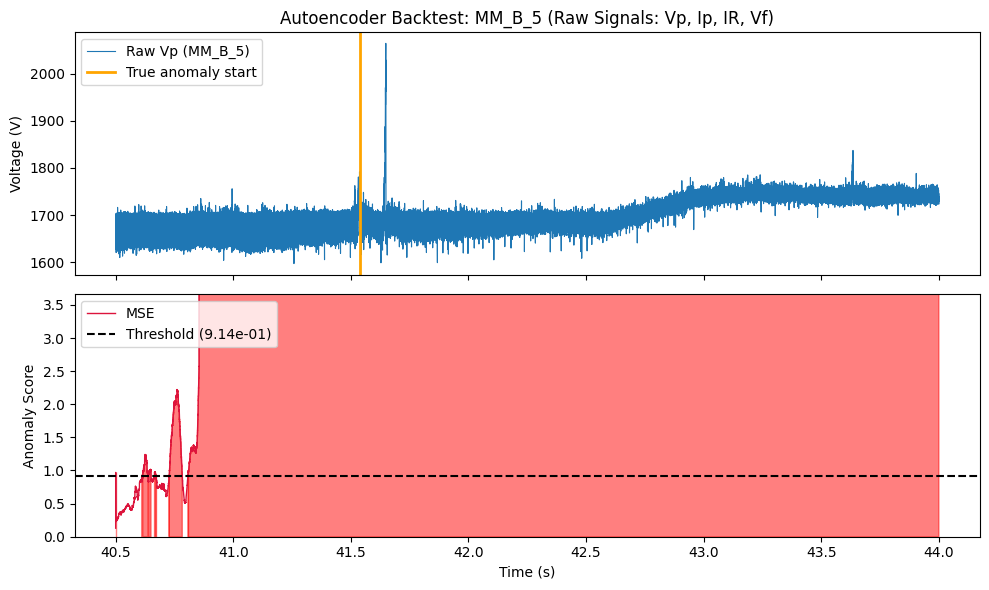

In [ ]:
CALIBRATION_POINTS = 1000
NUM_TRAIN_POINTS = 15000 
THRESHOLD_MARGIN = 1.2 

FEATURES_TO_USE = ['Vp_scaled', 'Ip_scaled', 'IR_scaled', 'Vf_scaled']

TRUE_ANOMALY_TIMES = {
    "MM_B_1": 1.6895, "MM_B_2": 6.4103, "MM_B_3": 43.9770,
    "MM_B_4": 127.6324, "MM_B_5": 41.5393
}

all_data = {}
vp_files = sorted(glob.glob("Fichiers/MM_B_*_Vp.txt"))

for vp_file in vp_files:
    b_id = os.path.basename(vp_file).split('_')[2]
    id_to_test = f"MM_B_{b_id}"
    
    # LOAD
    df = load_braking_data(b_id, variables=["Vp", "Ip", "IR", "Vf"])
    
    if df is not None:
        all_data[id_to_test] = prepare_raw_ae_features(df, CALIBRATION_POINTS)
    

# LOOCV
print("\n--- Starting LOOCV Evaluation with Raw Autoencoder ---")
for test_id, test_df in all_data.items():
    if test_id not in TRUE_ANOMALY_TIMES:
        continue
    
    train_dfs = [df for id_name, df in all_data.items() if id_name != test_id]
    
    # Train the 4-input Autoencoder
    test_results, threshold = train_and_predict_raw_ae(
        train_dfs, test_df, 
        feature_cols=FEATURES_TO_USE, 
        num_train_points=NUM_TRAIN_POINTS,
        threshold_margin=THRESHOLD_MARGIN
    )
    
    true_time = TRUE_ANOMALY_TIMES[test_id]
    evaluate_and_plot_raw_ae(test_results, threshold, true_time, test_id)

XGBoost

File MM_B_1: Ready.
File MM_B_2: Ready.
File MM_B_3: Ready.
File MM_B_4: Ready.
File MM_B_5: Ready.

  > True anomaly at: 1.6895s
  > First AI alarm raised at: 1.5675s
  SUCCESS: Correctly anticipated by 0.1220 sec.
  Total false alarms: 0


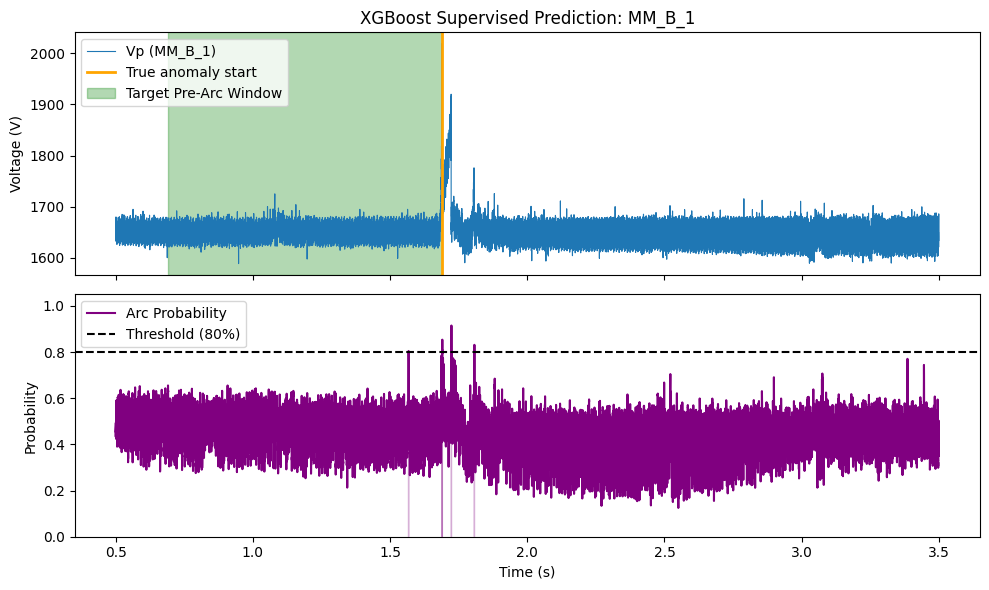


  > True anomaly at: 6.4103s
  > First AI alarm raised at: 6.4100s
  SUCCESS: Correctly anticipated by 0.0003 sec.
  Total false alarms: 0


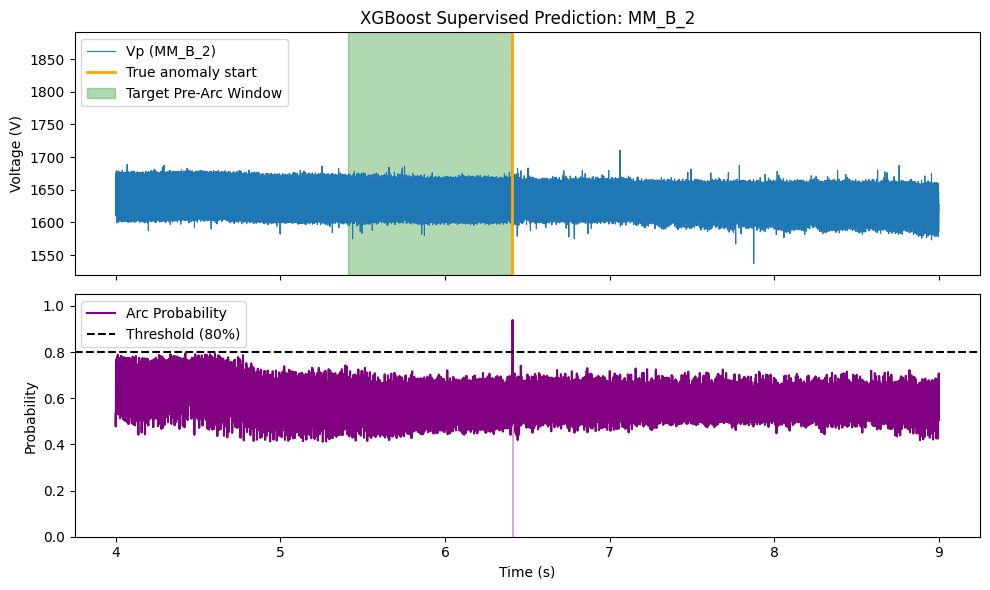


  > True anomaly at: 43.9770s
  > First AI alarm raised at: 43.9760s
  SUCCESS: Correctly anticipated by 0.0010 sec.
  Total false alarms: 0


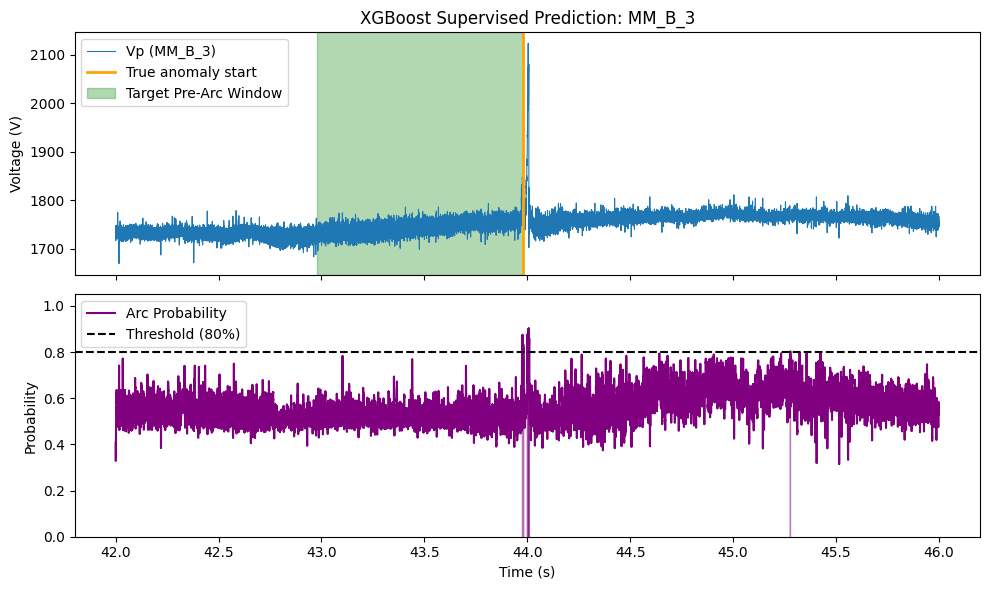


  > True anomaly at: 127.6324s
  > First AI alarm raised at: 126.1649s
  PREMATURE: Alarm triggered 1.4675 sec too early.
  Total false alarms: 12


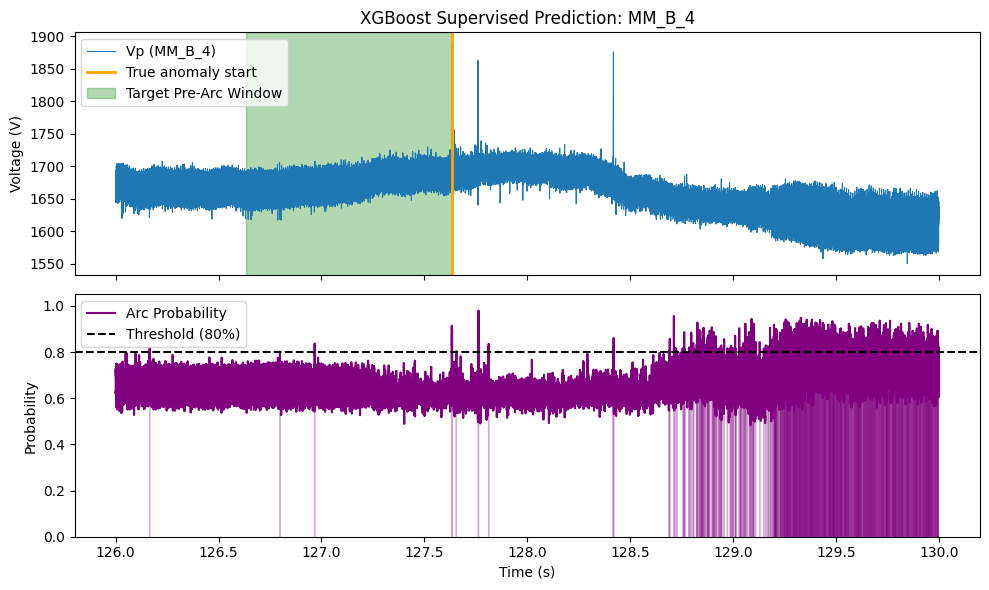


  > True anomaly at: 41.5393s
  > First AI alarm raised at: 41.5177s
  SUCCESS: Correctly anticipated by 0.0216 sec.
  Total false alarms: 0


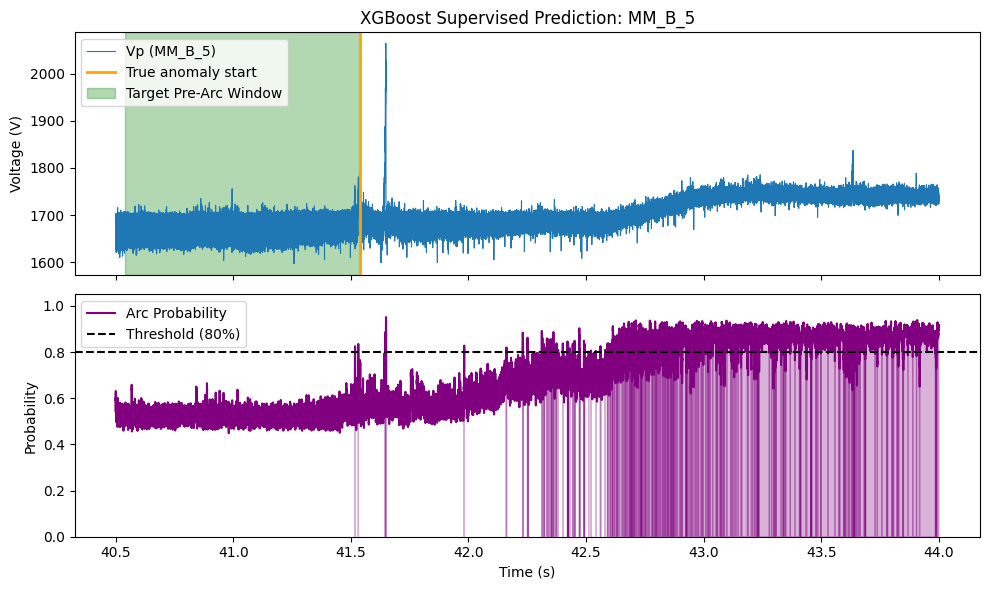

In [ ]:
WINDOW_SIZE = 50
CALIBRATION_POINTS = 1000

TRAIN_LOOKBACK_SEC = 5.0
TARGET_PRE_ARC_SEC = 1 
TARGET_POST_ARC_SEC = 0 
PROBABILITY_THRESHOLD = 0.8
SMOOTHING_WINDOW = 50 

FEATURES_TO_USE = ['Residual_scaled', 'Vp_Std_scaled', 'Vp_Speed_scaled','Ip_Vp_Corr_scaled']

TRUE_ANOMALY_TIMES = {
    "MM_B_1": 1.6895, "MM_B_2": 6.4103, "MM_B_3": 43.9770,
    "MM_B_4": 127.6324, "MM_B_5": 41.5393
}

#DATA AND FEATURES
all_data = {}
vp_files = sorted(glob.glob("Fichiers/MM_B_*_Vp.txt"))

for vp_file in vp_files:
    b_id = os.path.basename(vp_file).split('_')[2]
    id_to_test = f"MM_B_{b_id}"
    
    df = load_braking_data(b_id, variables=["Vp", "Ip"])
    if df is not None:
        all_data[id_to_test] = prepare_xgb_features(df, WINDOW_SIZE, CALIBRATION_POINTS)
        print(f"File {id_to_test}: Ready.")

# LOOCV
for test_id, test_df in all_data.items():
    if test_id not in TRUE_ANOMALY_TIMES:
        continue
           
    # 1. Create Supervised Training Data
    df_train = create_xgb_training_data(
        all_data, test_id, TRUE_ANOMALY_TIMES, 
        TRAIN_LOOKBACK_SEC, TARGET_PRE_ARC_SEC, TARGET_POST_ARC_SEC
    )
    
    # 2. Train and Predict
    test_results = train_and_predict_xgb(
        df_train, test_df, 
        feature_cols=FEATURES_TO_USE, 
        smoothing_window=SMOOTHING_WINDOW
    )
    
    # 3. Evaluate and Plot
    true_time = TRUE_ANOMALY_TIMES[test_id]
    evaluate_and_plot_xgb(test_results, PROBABILITY_THRESHOLD, true_time, TARGET_PRE_ARC_SEC, test_id)

LSTM

--- Loading and Local Calibration (LSTM) ---
File MM_B_1: Ready.
File MM_B_2: Ready.
File MM_B_3: Ready.
File MM_B_4: Ready.
File MM_B_5: Ready.

--- Starting LOOCV Evaluation with LSTM ---

> Evaluating test file: MM_B_1 using ['Residual_scaled', 'Vp_Std_scaled', 'Vp_Speed_scaled', 'Ip_Vp_Corr_scaled']

  > True anomaly at: 1.6895s
  > First AI alarm raised at: 0.5028s
  PREMATURE: Alarm triggered 1.1867 sec too early.
  Total false alarms: 1800


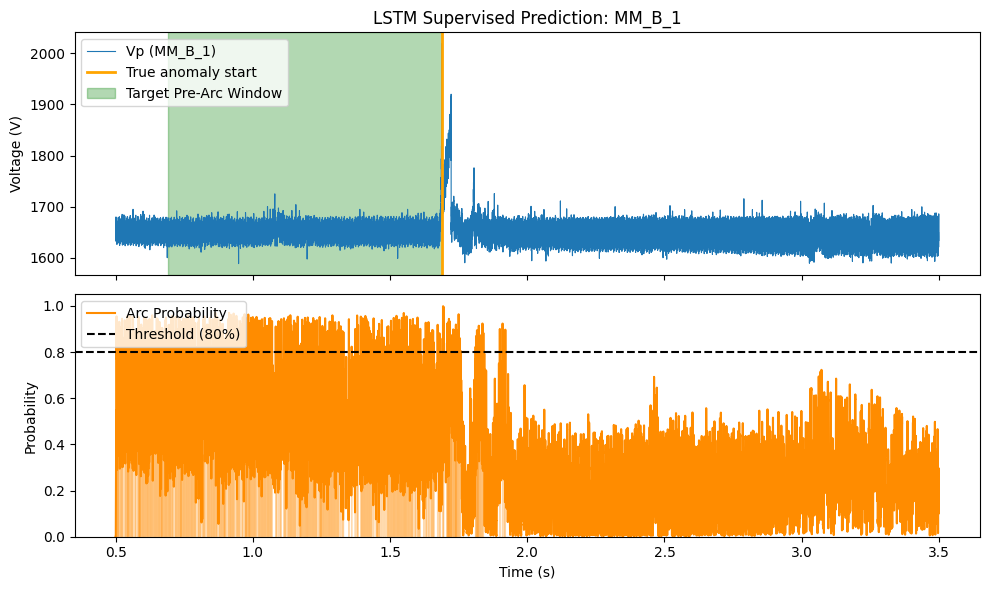


> Evaluating test file: MM_B_2 using ['Residual_scaled', 'Vp_Std_scaled', 'Vp_Speed_scaled', 'Ip_Vp_Corr_scaled']

  > True anomaly at: 6.4103s
  > First AI alarm raised at: 4.0017s
  PREMATURE: Alarm triggered 2.4086 sec too early.
  Total false alarms: 67028


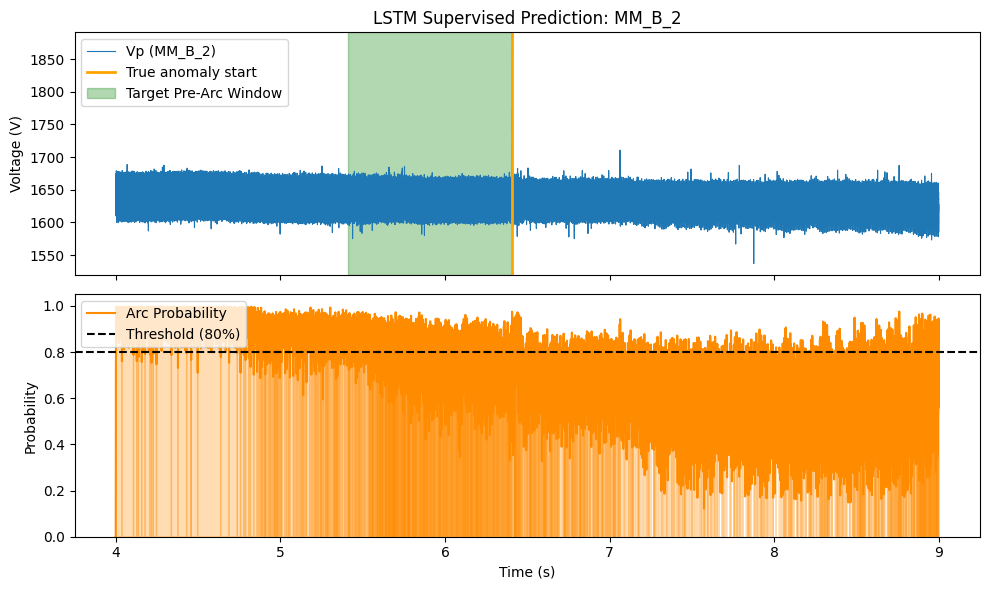


> Evaluating test file: MM_B_3 using ['Residual_scaled', 'Vp_Std_scaled', 'Vp_Speed_scaled', 'Ip_Vp_Corr_scaled']

  > True anomaly at: 43.9770s
  > First AI alarm raised at: 42.0028s
  PREMATURE: Alarm triggered 1.9742 sec too early.
  Total false alarms: 20856


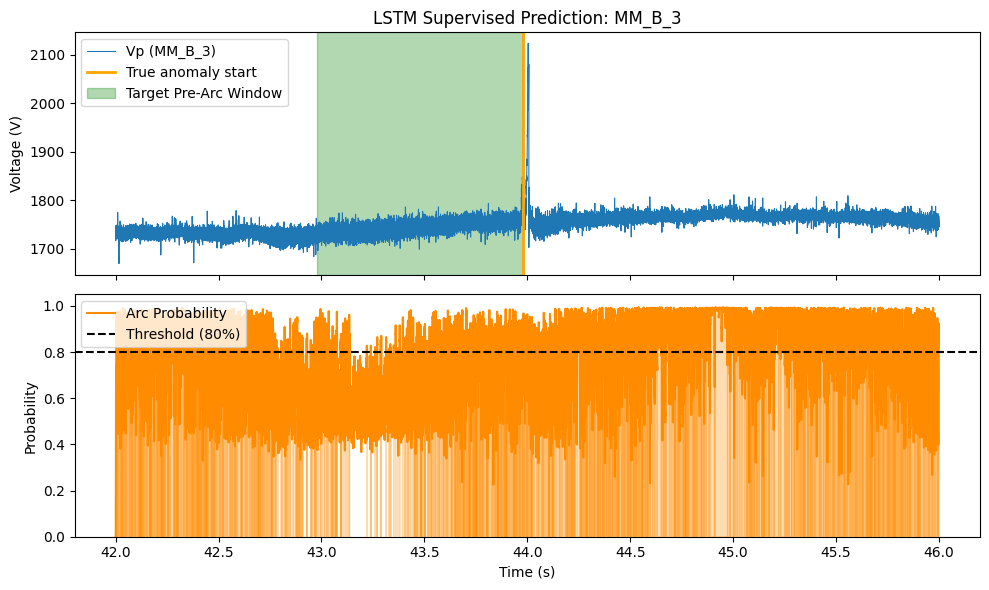


> Evaluating test file: MM_B_4 using ['Residual_scaled', 'Vp_Std_scaled', 'Vp_Speed_scaled', 'Ip_Vp_Corr_scaled']

  > True anomaly at: 127.6324s
  > First AI alarm raised at: 126.0014s
  PREMATURE: Alarm triggered 1.6310 sec too early.
  Total false alarms: 20335


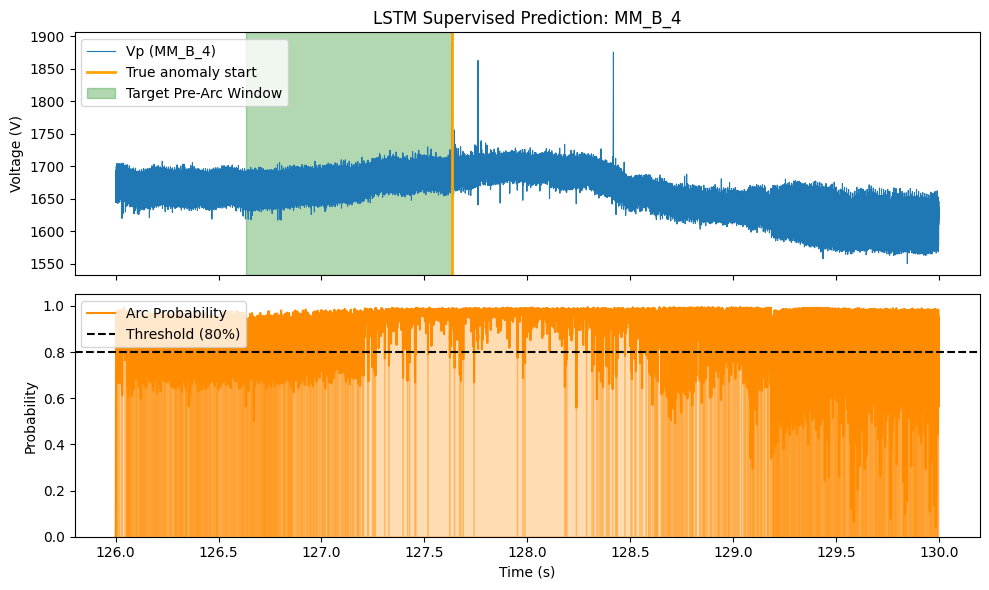


> Evaluating test file: MM_B_5 using ['Residual_scaled', 'Vp_Std_scaled', 'Vp_Speed_scaled', 'Ip_Vp_Corr_scaled']

  > True anomaly at: 41.5393s
  > First AI alarm raised at: 40.5022s
  PREMATURE: Alarm triggered 1.0371 sec too early.
  Total false alarms: 464


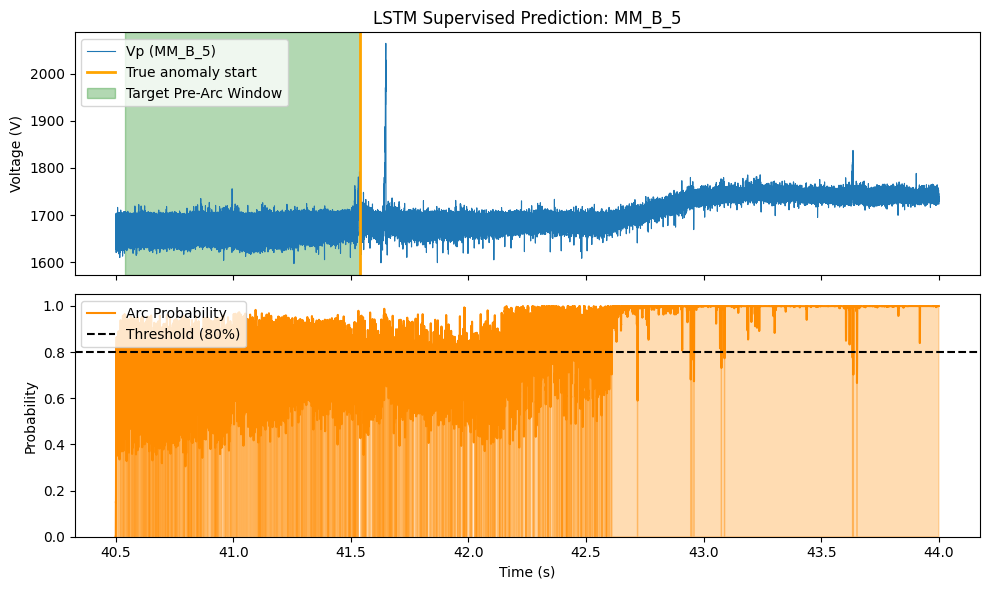

In [ ]:
import glob
import os
from EDA import load_braking_data
from LSTM import prepare_lstm_features, train_and_predict_lstm, evaluate_and_plot_lstm

# PARAMETERS
PARAMS = {
    'window_size': 50,
    'calib_points': 1000,
    'lookback': 5.0,
    'pre_target': 1.0,
    'post_target': 0.0,
    'time_steps': 20,       
    'smoothing': 200
}

THRESHOLD = 0.95
FEATURES_TO_USE = ['Residual_scaled', 'Vp_Std_scaled', 'Vp_Speed_scaled', 'Ip_Vp_Corr_scaled']

TRUE_ANOMALY_TIMES = {
    "MM_B_1": 1.6895, "MM_B_2": 6.4103, "MM_B_3": 43.9770,
    "MM_B_4": 127.6324, "MM_B_5": 41.5393
}

# DATA LOADING
print("--- Loading and Local Calibration (LSTM) ---")
all_data = {}
vp_files = sorted(glob.glob("Fichiers/MM_B_*_Vp.txt"))

for vp_file in vp_files:
    b_id = os.path.basename(vp_file).split('_')[2]
    id_to_test = f"MM_B_{b_id}"
    
    df = load_braking_data(b_id, variables=["Vp", "Ip"])
    if df is not None:
        all_data[id_to_test] = prepare_lstm_features(df, PARAMS['window_size'], PARAMS['calib_points'])
        print(f"File {id_to_test}: Ready.")

# LOOCV
print("\n--- Starting LOOCV Evaluation with LSTM ---")
for test_id in all_data.keys():
    if test_id not in TRUE_ANOMALY_TIMES:
        continue
    
    test_results = train_and_predict_lstm(
        all_data, test_id, TRUE_ANOMALY_TIMES, 
        feature_cols=FEATURES_TO_USE, params=PARAMS
    )
    
    true_time = TRUE_ANOMALY_TIMES[test_id]
    evaluate_and_plot_lstm(test_results, THRESHOLD, true_time, PARAMS['pre_target'], test_id)